## TASK 3

#### Comprehensive Analysis of Pizza Place Sales Data

### 1. Import the required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### 2. Loading the Dataset needed for the analysis

In [4]:
orders = pd.read_csv(r"C:\Users\HomePC\Downloads\orders.csv")

orders

,order_id,date,time
0,1,2015-01-01,11:38:36
1,2,2015-01-01,11:57:40
2,3,2015-01-01,12:12:28
3,4,2015-01-01,12:16:31
4,5,2015-01-01,12:21:30
...,...,...,...
21345,21346,2015-12-31,20:51:07
21346,21347,2015-12-31,21:14:37
21347,21348,2015-12-31,21:23:10
21348,21349,2015-12-31,22:09:54


In [5]:
order_details = pd.read_csv(r"C:\Users\HomePC\Downloads\order_details.csv")

order_details.head()

,order_details_id,order_id,pizza_id,quantity
0,1,1,hawaiian_m,1
1,2,2,classic_dlx_m,1
2,3,2,five_cheese_l,1
3,4,2,ital_supr_l,1
4,5,2,mexicana_m,1


In [6]:
pizzas = pd.read_csv(r"C:\Users\HomePC\Downloads\pizzas.csv")

pizzas.head()

,pizza_id,pizza_type_id,size,price
0,bbq_ckn_s,bbq_ckn,S,12.75
1,bbq_ckn_m,bbq_ckn,M,16.75
2,bbq_ckn_l,bbq_ckn,L,20.75
3,cali_ckn_s,cali_ckn,S,12.75
4,cali_ckn_m,cali_ckn,M,16.75


In [7]:
pizza_types = pd.read_csv(r"C:\Users\HomePC\Downloads\pizza_types.csv", encoding = "latin1")

pizza_types.head()

,pizza_type_id,name,category,ingredients
0,bbq_ckn,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,..."
1,cali_ckn,The California Chicken Pizza,Chicken,"Chicken, Artichoke, Spinach, Garlic, Jalapeno ..."
2,ckn_alfredo,The Chicken Alfredo Pizza,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A..."
3,ckn_pesto,The Chicken Pesto Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Spinach, Garli..."
4,southw_ckn,The Southwest Chicken Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Red Onions, Ja..."


### 3. Merging the Datasets

In [8]:
# Merging order with order_details

df1 = pd.merge(orders, order_details, on ="order_id", how = "inner")

df1.head()

,order_id,date,time,order_details_id,pizza_id,quantity
0,1,2015-01-01,11:38:36,1,hawaiian_m,1
1,2,2015-01-01,11:57:40,2,classic_dlx_m,1
2,2,2015-01-01,11:57:40,3,five_cheese_l,1
3,2,2015-01-01,11:57:40,4,ital_supr_l,1
4,2,2015-01-01,11:57:40,5,mexicana_m,1


In [9]:
# Merge with pizza

df2 = pd.merge(df1, pizzas , on ="pizza_id", how = "inner" )

df2.head()

,order_id,date,time,order_details_id,pizza_id,quantity,pizza_type_id,size,price
0,1,2015-01-01,11:38:36,1,hawaiian_m,1,hawaiian,M,13.25
1,2,2015-01-01,11:57:40,2,classic_dlx_m,1,classic_dlx,M,16.00
2,2,2015-01-01,11:57:40,3,five_cheese_l,1,five_cheese,L,18.50
3,2,2015-01-01,11:57:40,4,ital_supr_l,1,ital_supr,L,20.75
4,2,2015-01-01,11:57:40,5,mexicana_m,1,mexicana,M,16.00


In [10]:
# merge with pizza type
pizza_sales_df = pd.merge(df2, pizza_types, on="pizza_type_id", how="inner")

pizza_sales_df

,order_id,date,time,order_details_id,pizza_id,quantity,pizza_type_id,size,price,name,category,ingredients
0,1,2015-01-01,11:38:36,1,hawaiian_m,1,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese"
1,2,2015-01-01,11:57:40,2,classic_dlx_m,1,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,..."
2,2,2015-01-01,11:57:40,3,five_cheese_l,1,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go..."
3,2,2015-01-01,11:57:40,4,ital_supr_l,1,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni..."
4,2,2015-01-01,11:57:40,5,mexicana_m,1,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O..."
...,...,...,...,...,...,...,...,...,...,...,...,...
48615,21348,2015-12-31,21:23:10,48616,ckn_alfredo_m,1,ckn_alfredo,M,16.75,The Chicken Alfredo Pizza,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A..."
48616,21348,2015-12-31,21:23:10,48617,four_cheese_l,1,four_cheese,L,17.95,The Four Cheese Pizza,Veggie,"Ricotta Cheese, Gorgonzola Piccante Cheese, Mo..."
48617,21348,2015-12-31,21:23:10,48618,napolitana_s,1,napolitana,S,12.00,The Napolitana Pizza,Classic,"Tomatoes, Anchovies, Green Olives, Red Onions,..."
48618,21349,2015-12-31,22:09:54,48619,mexicana_l,1,mexicana,L,20.25,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O..."


In [11]:
pizza_sales_df.head()

,order_id,date,time,order_details_id,pizza_id,quantity,pizza_type_id,size,price,name,category,ingredients
0,1,2015-01-01,11:38:36,1,hawaiian_m,1,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese"
1,2,2015-01-01,11:57:40,2,classic_dlx_m,1,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,..."
2,2,2015-01-01,11:57:40,3,five_cheese_l,1,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go..."
3,2,2015-01-01,11:57:40,4,ital_supr_l,1,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni..."
4,2,2015-01-01,11:57:40,5,mexicana_m,1,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O..."


In [12]:
pizza_sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          48620 non-null  int64  
 1   date              48620 non-null  object 
 2   time              48620 non-null  object 
 3   order_details_id  48620 non-null  int64  
 4   pizza_id          48620 non-null  object 
 5   quantity          48620 non-null  int64  
 6   pizza_type_id     48620 non-null  object 
 7   size              48620 non-null  object 
 8   price             48620 non-null  float64
 9   name              48620 non-null  object 
 10  category          48620 non-null  object 
 11  ingredients       48620 non-null  object 
dtypes: float64(1), int64(3), object(8)
memory usage: 4.5+ MB


In [13]:
pizza_sales_df.isna().sum()

order_id            0
date                0
time                0
order_details_id    0
pizza_id            0
quantity            0
pizza_type_id       0
size                0
price               0
name                0
category            0
ingredients         0
dtype: int64

In [14]:
# Convert Date
pizza_sales_df['date'] = pd.to_datetime(pizza_sales_df['date'])


In [15]:
pizza_sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          48620 non-null  int64         
 1   date              48620 non-null  datetime64[ns]
 2   time              48620 non-null  object        
 3   order_details_id  48620 non-null  int64         
 4   pizza_id          48620 non-null  object        
 5   quantity          48620 non-null  int64         
 6   pizza_type_id     48620 non-null  object        
 7   size              48620 non-null  object        
 8   price             48620 non-null  float64       
 9   name              48620 non-null  object        
 10  category          48620 non-null  object        
 11  ingredients       48620 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(3), object(7)
memory usage: 4.5+ MB


## Recommended Analysis
#### 1. What is the total revenue/ sales
To find the total revenue/sales, we calculate price * quantity

In [16]:
# Add revenue column

pizza_sales_df['revenue'] = pizza_sales_df["price"] * pizza_sales_df["quantity"]

pizza_sales_df.head()

,order_id,date,time,order_details_id,pizza_id,quantity,pizza_type_id,size,price,name,category,ingredients,revenue
0,1,2015-01-01,11:38:36,1,hawaiian_m,1,hawaiian,M,13.25,The Hawaiian Pizza,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",13.25
1,2,2015-01-01,11:57:40,2,classic_dlx_m,1,classic_dlx,M,16.00,The Classic Deluxe Pizza,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",16.00
2,2,2015-01-01,11:57:40,3,five_cheese_l,1,five_cheese,L,18.50,The Five Cheese Pizza,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",18.50
3,2,2015-01-01,11:57:40,4,ital_supr_l,1,ital_supr,L,20.75,The Italian Supreme Pizza,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",20.75
4,2,2015-01-01,11:57:40,5,mexicana_m,1,mexicana,M,16.00,The Mexicana Pizza,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",16.00


In [17]:
# The total revenue/ sales

total_revenue = pizza_sales_df['revenue'].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 817860.05


#### 2. Find the total quantity sold.

In [18]:
total_quantity_sold = pizza_sales_df["quantity"].sum()

print("Total Quantity Sold:" , total_quantity_sold)

Total Quantity Sold: 49574


#### 3. Total Order

In [19]:
total_orders = pizza_sales_df['order_id'].nunique()

print("Total Orders:", total_orders)

Total Orders: 21350


#### 4. How many pizza types do they sell?

In [20]:
number_pizza_types = pizza_sales_df['name'].nunique()
print("Number of Pizza Types Sold:", number_pizza_types)


Number of Pizza Types Sold: 32


#### 5. Average Price of Pizza

In [21]:
# we calculate the average price of pizza sold using the .mean() function on the price

average_price = pizza_sales_df['price'].mean()

print("Average Pizza Price:", average_price)

Average Pizza Price: 16.494132044426163


#### 6. Peak Hours of Sales

To find the peak hours of sales, we convert the time column from object type to datetime format.
Then, we extract the hour from it to analyze sales distribution by hour.

In [22]:
pizza_sales_df['time'] = pd.to_datetime(pizza_sales_df['time'], format='%H:%M:%S').dt.hour

In [23]:
peak_hours = pizza_sales_df.groupby('time')['order_id'].nunique().sort_values(ascending=False)

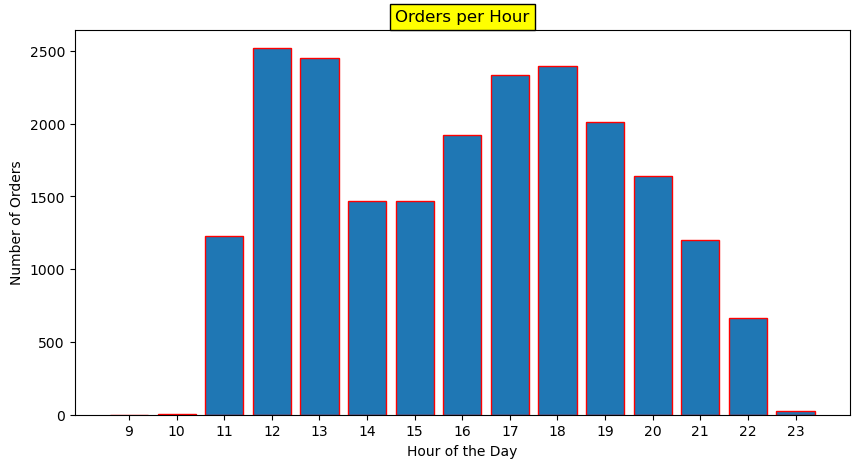

In [42]:
plt.figure(figsize =(10,5))

plt.bar(peak_hours.index, peak_hours.values , edgecolor='red')
plt.xticks(peak_hours.index)
plt.title("Orders per Hour", bbox=dict(facecolor='yellow'))
plt.xlabel("Hour of the Day")
plt.ylabel("Number of Orders")

plt.show()


#### 7. Find the total sales made on each day of the week. Which day of the week is when sales are made the most?

In [25]:
pizza_sales_df['day_of_week'] = pizza_sales_df['date'].dt.day_name()

# The total sales made on each day of the week
sales_by_day = pizza_sales_df.groupby('day_of_week')['revenue'].sum().sort_values(ascending = True)

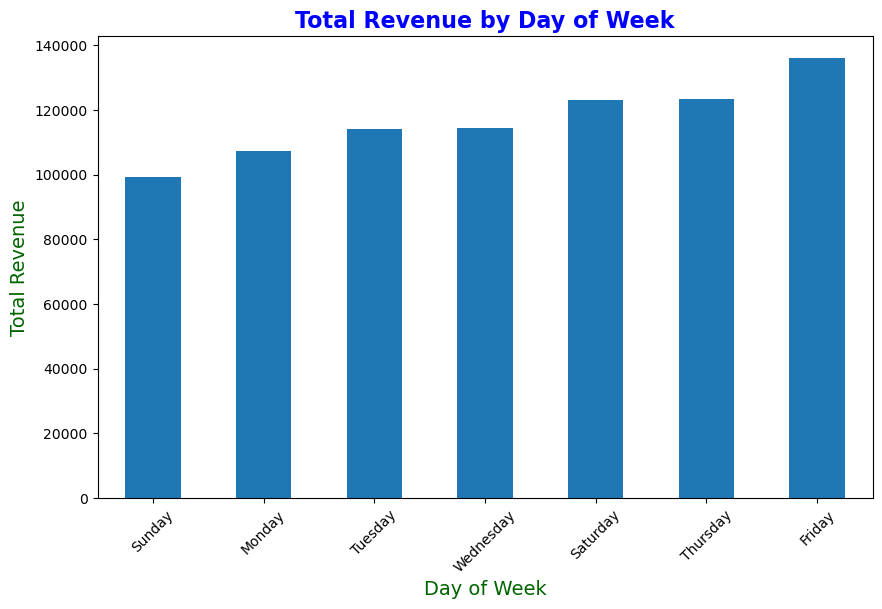

In [36]:
# To find which day of the week is when sales are made the most


plt.figure(figsize=(10,6))

sales_by_day.plot(kind ="bar")
plt.title('Total Revenue by Day of Week', fontsize=16, weight='bold', color='blue')
plt.xlabel('Day of Week', color='darkgreen', fontsize=14 )
plt.ylabel('Total Revenue' ,color='darkgreen', fontsize=14)

plt.xticks(rotation=45)
plt.show()

Insight 

From the bar chart above, Friday recorded the higest total sales, making it the most profitable day of the week.

#### 8. Top 5 Bestselling Pizzas

In [28]:
#The Top 5 Best selling
top_5_pizzas = pizza_sales_df.groupby('name')['quantity'].sum().sort_values(ascending=False).head()

top_5_pizzas

name
The Classic Deluxe Pizza      2453
The Barbecue Chicken Pizza    2432
The Hawaiian Pizza            2422
The Pepperoni Pizza           2418
The Thai Chicken Pizza        2371
Name: quantity, dtype: int64

#### 9. Find the sales made in each month. Any trend noticeable?


In [29]:
# Extract month num from the month dtype
pizza_sales_df['month_num'] = pizza_sales_df['date'].dt.month
pizza_sales_df['month_name'] = pizza_sales_df['date'].dt.strftime('%B')

monthly_sales = pizza_sales_df.groupby(['month_num', 'month_name'])['revenue'].sum() .sort_index()


In [30]:
monthly_sales = pizza_sales_df.groupby(['month_num', 'month_name'])['revenue'].sum().reset_index()



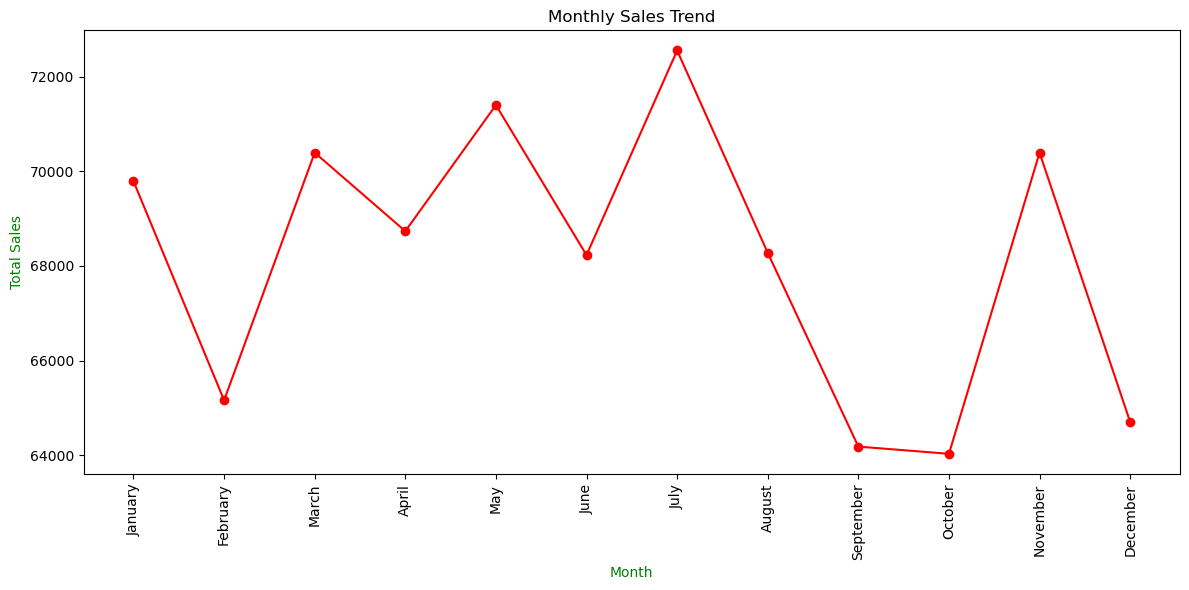

In [37]:
plt.figure(figsize=(12,6))

plt.plot(monthly_sales['month_name'], monthly_sales['revenue'], marker='o', color ='red')

plt.title("Monthly Sales Trend")
plt.xlabel("Month",  color = 'green')
plt.ylabel("Total Sales",color = 'green')

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

From the visualization(line chart) above which shows total sales for each month of the year.it is noticeable that:


The monthly sales show some changes throughout the year. Sales increase from January and reach the highest point in July. After July, sales start to decrease, especially in September and October,a noticeable decline occurs in September and October, followed by a slight recovery in November. Overall, sales are higher in the middle of the year and lower towards the end and indicating a mid-year peak in demand.

#### 10. Are there pizza types that are not doing well on the menu?


In [32]:


pizza_performance = pizza_sales_df.groupby('name')['quantity'].sum().sort_values()


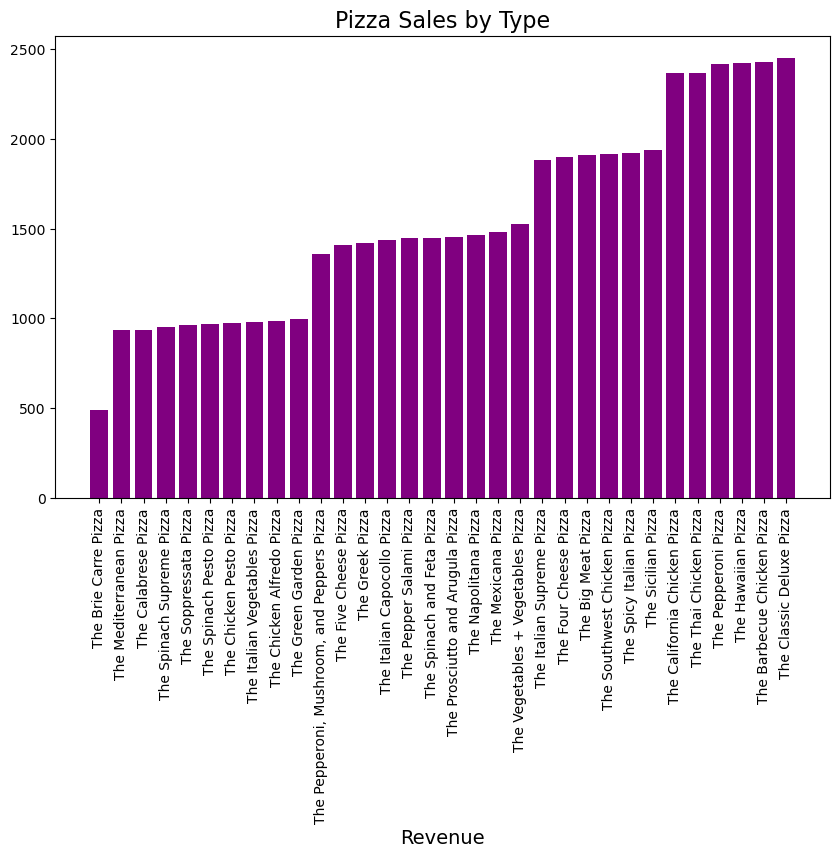

In [39]:
plt.figure(figsize=(10,6))

plt.bar(pizza_performance.index,  pizza_performance.values, color='purple')
plt.xlabel("Revenue",  fontsize=14, color = 'black')
plt.xticks(rotation = 90)
plt.title("Pizza Sales by Type",  fontsize=16)
plt.show()


Bar chart shows the sales performance of each pizza type.

Pizzas with the shortest bars, have the lowest sales, indicating that they are underperforming on the menu.